In [171]:
!uv pip install numpy pandas matplotlib nltk pythainlp scikit-learn

Checked 6 packages in 2ms


In [172]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/kami/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/kami/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/kami/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [173]:
train = pd.read_csv('./financial-news-data/financial-news-train.csv', encoding='utf-8')
test = pd.read_csv('./financial-news-data/financial-news-test.csv', encoding='utf-8')

In [174]:
def clean_text_dataframe(df, drop_duplicates=True):

    if drop_duplicates:
        df.drop_duplicates(subset=['text'], inplace=True)

    # Lowercase
    df['text'] = df['text'].str.lower()

    # Remove quotes
    df['text'] = df['text'].str.replace('"', 'TWITTER_HANDLE', regex=False)

    # Remove links
    df['text'] = df['text'].str.replace(r'https?://\S+', 'URL', regex=True)

    # Remove words that don't start with an alphabetic character
    # Too destructive
    df['text'] = df['text'].str.replace(r'\b[^a-z\s]\S*', '', regex=True)

    # Remove non-alphabetic characters
    df['text'] = df['text'].str.replace(r'[^a-z\s]', '', regex=True)

    # Normalize whitespace after removals
    df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # NLTK remove stopwods
    stop_words = set(stopwords.words('english'))
    df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

In [175]:
# Show full text
pd.set_option('display.max_colwidth', None)

clean_text_dataframe(train)
clean_text_dataframe(test, drop_duplicates=False)

train

,text,label
0,thursday biggest analyst calls apple amazon tesla palantir docusign exxon amp,Analyst Update
1,buy las vegas sands travel singapore builds wells fargo says,Analyst Update
2,piper sandler downgrades docusign sell citing elevated risks amid ceo transition,Analyst Update
3,analysts react tesla latest earnings break next electric car maker,Analyst Update
4,netflix peers set return growth analysts say giving one stock upside,Analyst Update
...,...,...
16985,kfw credit line uniper could raised bln eur handelsblatt,Treasuries | Corporate Debt
16986,kfw credit line uniper could raised bln eur handelsblatt,Treasuries | Corporate Debt
16987,russian sells bln roubles one repo auction,Treasuries | Corporate Debt
16988,global esg bond issuance posts h dip supranationals cut back,Treasuries | Corporate Debt


In [176]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(train['text'])
X_test = vectorizer.transform(test['text'])

In [177]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=5, max_df=0.8)
# X_train = vectorizer.fit_transform(train['text'])
# X_test = vectorizer.transform(test['text'])# 

In [178]:
vectorizer.get_feature_names_out()

array(['aa', 'aad', 'aaic', ..., 'zynx', 'zyus', 'zyversa'],
      shape=(21169,), dtype=object)

In [179]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(train['label'])
y_test = encoder.transform(test['label'])

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, fit_intercept=False, random_state=4432)
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [181]:
pred = model.predict(X_test)

In [182]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

#Q1

print("Classification Report:")
print(classification_report(
    y_test,
    pred,
    target_names=encoder.classes_,
    digits=3,
    zero_division=0
))

Classification Report:
                             precision    recall  f1-score   support

             Analyst Update      0.885     0.630     0.736        73
     Company | Product News      0.798     0.881     0.838       852
                 Currencies      0.786     0.688     0.733        32
                   Dividend      0.979     0.979     0.979        97
                   Earnings      0.918     0.921     0.920       242
               Energy | Oil      0.803     0.808     0.805       146
        Fed | Central Banks      0.844     0.836     0.840       214
                 Financials      0.863     0.825     0.843       160
     General News | Opinion      0.744     0.726     0.735       336
  Gold | Metals | Materials      0.500     0.692     0.581        13
                        IPO      0.818     0.643     0.720        14
         Legal | Regulation      0.931     0.790     0.855       119
          M&A | Investments      0.788     0.672     0.726       116
          

In [183]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

#Q1

print("Classification Report:")
print(classification_report(
    y_test,
    pred,
    target_names=encoder.classes_,
    digits=3,
    zero_division=0
))

Classification Report:
                             precision    recall  f1-score   support

             Analyst Update      0.885     0.630     0.736        73
     Company | Product News      0.798     0.881     0.838       852
                 Currencies      0.786     0.688     0.733        32
                   Dividend      0.979     0.979     0.979        97
                   Earnings      0.918     0.921     0.920       242
               Energy | Oil      0.803     0.808     0.805       146
        Fed | Central Banks      0.844     0.836     0.840       214
                 Financials      0.863     0.825     0.843       160
     General News | Opinion      0.744     0.726     0.735       336
  Gold | Metals | Materials      0.500     0.692     0.581        13
                        IPO      0.818     0.643     0.720        14
         Legal | Regulation      0.931     0.790     0.855       119
          M&A | Investments      0.788     0.672     0.726       116
          

In [184]:
model_weights = pd.DataFrame(model.coef_, columns=vectorizer.get_feature_names_out(), index=encoder.classes_).T
model_weights

,Analyst Update,Company | Product News,Currencies,Dividend,Earnings,Energy | Oil,Fed | Central Banks,Financials,General News | Opinion,Gold | Metals | Materials,IPO,Legal | Regulation,M&A | Investments,Macro,Markets,Personnel Change,Politics,Stock Commentary,Stock Movement,Treasuries | Corporate Debt
aa,0.524935,-0.051724,-0.040145,-0.025935,-0.100691,-0.043032,-0.040740,-0.015543,-0.051853,-0.041076,-0.023653,-0.029895,-0.030254,-0.198481,-0.096220,-0.027485,-0.034235,0.278814,0.092829,-0.045614
aad,-0.002134,0.125744,-0.003136,-0.002940,-0.004886,-0.002790,-0.003218,-0.002759,-0.029580,-0.002975,-0.002960,-0.006630,-0.003877,-0.001497,-0.002878,-0.041002,-0.003007,-0.002083,-0.004338,-0.003052
aaic,-0.000997,-0.055923,-0.001271,-0.000607,-0.001988,-0.001342,-0.001329,-0.000727,-0.007689,-0.001091,-0.000831,-0.000622,-0.001107,-0.000953,-0.002128,-0.001258,-0.001269,0.097458,-0.015228,-0.001099
aaii,-0.000419,-0.002435,-0.001888,-0.000580,-0.002654,-0.000660,-0.001147,-0.000640,-0.000802,-0.000931,-0.000523,-0.000370,-0.001331,0.108863,-0.000527,-0.000557,-0.000600,-0.091391,-0.000597,-0.000811
aal,-0.192277,0.199706,-0.047557,-0.039638,0.332407,-0.252871,-0.061864,0.066611,-0.210446,-0.044934,-0.043573,-0.054538,-0.075931,-0.256328,-0.092913,-0.091724,-0.060840,0.650620,0.337053,-0.060963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zynerba,-0.000391,-0.007141,-0.000385,-0.000387,-0.000338,-0.000419,-0.000481,-0.000520,-0.002105,-0.000359,-0.000377,-0.002307,-0.011089,-0.000435,-0.000446,-0.000395,-0.000370,-0.000486,0.029160,-0.000729
zynlonta,-0.000277,0.006679,-0.000288,-0.000374,-0.000332,-0.000283,-0.000296,-0.000445,-0.000318,-0.000283,-0.000275,-0.000313,-0.000312,-0.000315,-0.000302,-0.000523,-0.000326,-0.000298,-0.000785,-0.000332
zynx,-0.002596,0.166099,-0.001423,-0.002746,-0.001841,-0.001542,-0.001321,-0.005287,-0.043448,-0.002056,-0.003101,-0.004797,-0.044619,-0.017987,-0.001744,-0.005251,-0.003724,-0.015493,-0.003677,-0.003447
zyus,-0.005819,0.372344,-0.004730,-0.058020,-0.004586,-0.123074,-0.008201,-0.006835,-0.046415,-0.005041,-0.006043,-0.010799,-0.020183,-0.015328,-0.007363,-0.007233,-0.004469,-0.010082,-0.011674,-0.016450


In [185]:
model_weights.to_csv('model_weights.csv', index=True)

In [186]:
#Q2

best_weights = []
worst_weights = []

# Get 2 best performing labels based on F1 score
f1_scores = f1_score(y_test, pred, average=None)
best_labels = f1_scores.argsort()[::-1][:2]
best_labels_name = encoder.inverse_transform(best_labels)

print(best_labels_name)

['Dividend' 'Earnings']


In [187]:
for label in best_labels_name:
    print(f"\nTop 10 features for label '{label}':")
    top_features = model_weights[label].sort_values(ascending=False).head(10)
    print(top_features)
    best_weights.append(top_features.tolist())


Top 10 features for label 'Dividend':
dividend         4.801879
distribution     2.542626
declares         2.503276
distributions    1.421994
dividends        1.276408
quarterly        1.240435
trust            1.220371
announces        1.152866
ex               1.043154
reit             0.920280
Name: Dividend, dtype: float64

Top 10 features for label 'Earnings':
earnings      4.860137
results       3.678312
preview       1.879023
quarter       1.763123
call          1.730968
upcoming      1.549104
conference    1.289248
reports       1.271589
ms            1.251391
est           1.150447
Name: Earnings, dtype: float64


In [188]:
# Q3

# Get 2 worst performing labels based on F1 score
worst_labels = f1_scores.argsort()[::-1][-2:]
worst_labels_name = encoder.inverse_transform(worst_labels)

print(worst_labels_name)

for label in worst_labels_name:
    print(f"\nTop 10 features for label '{label}':")
    top_features = model_weights[label].sort_values(ascending=False).head(10)
    print(top_features)
    worst_weights.append(top_features.tolist())

['IPO' 'Gold | Metals | Materials']

Top 10 features for label 'IPO':
ipo        4.262988
ipos       1.266048
public     1.063278
spac       0.820034
go         0.762953
listing    0.672435
kong       0.664788
hong       0.664788
dubai      0.626683
porsche    0.619980
Name: IPO, dtype: float64

Top 10 features for label 'Gold | Metals | Materials':
gold         3.641639
copper       1.799218
metals       1.679292
dollar       1.047368
gld          0.857155
nickel       0.782815
drops        0.746163
silver       0.680722
base         0.672997
investors    0.654793
Name: Gold | Metals | Materials, dtype: float64


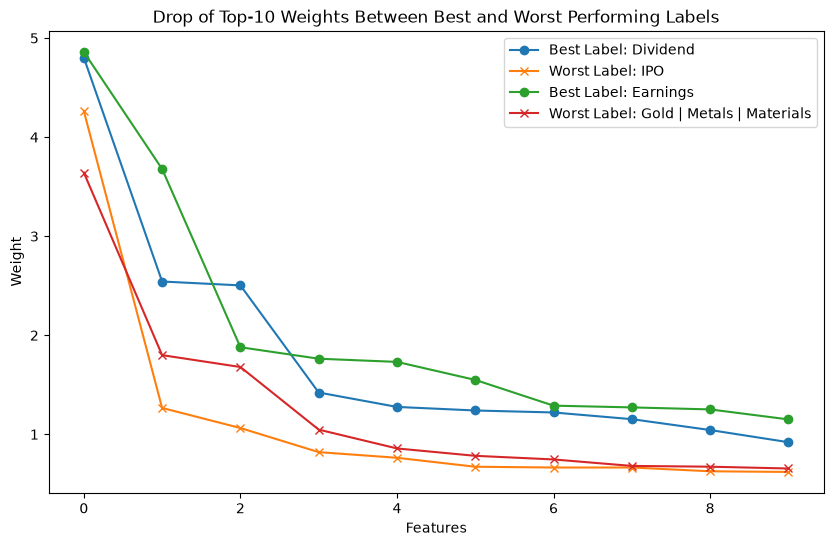

In [189]:
import matplotlib.pyplot as plt

# plot the drop of the top-10 weight between the best and worst performing labels
plt.figure(figsize=(10, 6))
plt.xlabel('Features')
plt.ylabel('Weight')
plt.title('Drop of Top-10 Weights Between Best and Worst Performing Labels')

# Plot
for i in range(2):
    plt.plot(range(10), best_weights[i], marker='o', label=f'Best Label: {best_labels_name[i]}')
    plt.plot(range(10), worst_weights[i], marker='x', label=f'Worst Label: {worst_labels_name[i]}')

# Legend
plt.legend()

plt.show()

In [190]:
# Check frequency of the word 'earnings' in the training data grouped by each label and show the percentage of the portion
train['earnings_count'] = train['text'].apply(lambda x: x.split().count('dividend'))
earnings_count_by_label = train.groupby('label')['earnings_count'].sum()
earnings_count_by_label

label
Analyst Update                   1
Company | Product News           0
Currencies                       0
Dividend                       281
Earnings                         3
Energy | Oil                     0
Fed | Central Banks              0
Financials                       3
General News | Opinion           0
Gold | Metals | Materials        0
IPO                              0
Legal | Regulation               0
M&A | Investments                0
Macro                            1
Markets                          0
Personnel Change                 0
Politics                         3
Stock Commentary                47
Stock Movement                   2
Treasuries | Corporate Debt      0
Name: earnings_count, dtype: int64

In [191]:
# Count the label in the training data
train['label'].value_counts()

label
Company | Product News         3398
Stock Commentary               1997
Macro                          1516
General News | Opinion         1300
Earnings                        977
Politics                        890
Stock Movement                  807
Fed | Central Banks             710
Financials                      606
Personnel Change                490
Markets                         467
Energy | Oil                    460
M&A | Investments               459
Legal | Regulation              457
Dividend                        359
Analyst Update                  253
Treasuries | Corporate Debt     253
Currencies                      150
Gold | Metals | Materials        60
IPO                              42
Name: count, dtype: int64

In [192]:
train['label'].__len__

<bound method Series.__len__ of 0                     Analyst Update
1                     Analyst Update
2                     Analyst Update
3                     Analyst Update
4                     Analyst Update
                    ...             
16985    Treasuries | Corporate Debt
16986    Treasuries | Corporate Debt
16987    Treasuries | Corporate Debt
16988    Treasuries | Corporate Debt
16989    Treasuries | Corporate Debt
Name: label, Length: 15651, dtype: str>

In [193]:
(58+42)/16989

0.005886161633998469